# CS4440 Final Project
## Tsunami Prediction using Random Forest

### Members
- Angie Kim
- Edgar Ortiz
- Jason Mar
- Joshua Estrada
- Michael Castillo

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('earthquake_data_tsunami.csv')

print(f"Dataset Shape: {data.shape[0]} rows x {data.shape[1]} columns")

# Convert latitude/longitude (degrees) to 3D Cartesian coordinates (radians)
data['latitude'] = data['latitude'].astype(float)
data['longitude'] = data['longitude'].astype(float)
lat_rad = np.deg2rad(data['latitude'])
lon_rad = np.deg2rad(data['longitude'])
data['X_cart'] = np.cos(lat_rad) * np.cos(lon_rad)
data['Y_cart'] = np.cos(lat_rad) * np.sin(lon_rad)
data['Z_cart'] = np.sin(lat_rad)

# Prepare features and labels (drop original lat/lon if using Cartesian coords)
X = data.drop(['tsunami', 'Year', 'Month', 'latitude', 'longitude'], axis=1)
y = data['tsunami']

# Split the data into training, testing, and validation sets, 80/10/10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# split the 20% temp into two equal halves -> 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset Shape: 782 rows x 13 columns
Training set size: 625 samples
Validation set size: 78 samples
Testing set size: 79 samples


In [2]:
data.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami,X_cart,Y_cart,Z_cart
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1,-0.923591,0.343554,-0.170146
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0,-0.185622,0.978816,-0.086389
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1,-0.938998,-0.027114,-0.342853
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1,-0.934956,-0.129254,-0.330379
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1,-0.901464,0.027101,-0.432004


**Checking Relative Percentages of minority class:**

In [3]:
print('\nSplit sizes:')
print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('\nClass counts by split:')
print('Train:\n', y_train.value_counts())
print('Validation:\n', y_val.value_counts())
print('Test:\n', y_test.value_counts())

print('\nPercentages (relative to full dataset):')
print(f"Train%: {len(y_train)/len(data):.4f}")
print(f"Validation%: {len(y_val)/len(data):.4f}")
print(f"Test%: {len(y_test)/len(data):.4f}")



Split sizes:
Train: (625, 11) Validation: (78, 11) Test: (79, 11)

Class counts by split:
Train:
 tsunami
0    382
1    243
Name: count, dtype: int64
Validation:
 tsunami
0    48
1    30
Name: count, dtype: int64
Test:
 tsunami
0    48
1    31
Name: count, dtype: int64

Percentages (relative to full dataset):
Train%: 0.7992
Validation%: 0.0997
Test%: 0.1010


In [4]:
missing_values = data.isnull().sum().sum()
print(f"Missing Values: {missing_values}")

dupes = data.duplicated().sum()
print(f"Duplicates: {dupes}")

Missing Values: 0
Duplicates: 0


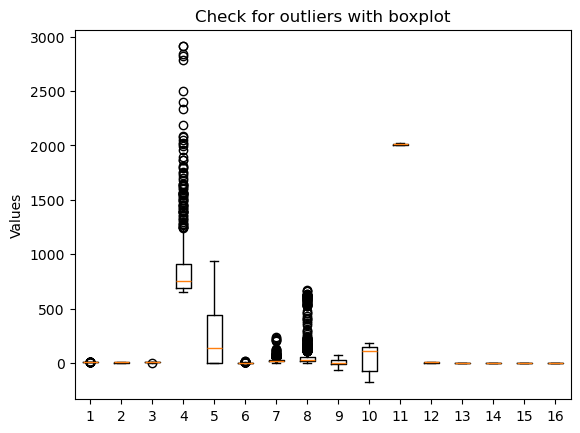

In [5]:
import matplotlib.pyplot as plt
plt.boxplot(data)
plt.title("Check for outliers with boxplot")
plt.ylabel("Values")
plt.show()

### Standardizing using Robust Scaler 

In [6]:
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

# Select numeric columns to scale
numeric_cols = ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 
                'X_cart', 'Y_cart', 'Z_cart']
# Filter to only those present in X_train
numeric_cols = [c for c in numeric_cols if c in X_train.columns]
print('Numeric columns to scale:', numeric_cols)

# Initialize and fit scaler on TRAIN data only
scaler = RobustScaler()
scaler.fit(X_train[numeric_cols])

# Transform train, val, and test sets
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'\nScaled training set shape: {X_train_scaled.shape}')

# Train Random Forest classifier
print('\nTraining Random Forest...')
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# Predict on validation and test sets
y_val_pred = clf.predict(X_val_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Validation metrics
print('\n' + '='*50)
print('VALIDATION SET RESULTS')
print('='*50)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')
print(f'Accuracy:  {val_accuracy:.4f}')
print(f'Precision: {val_precision:.4f}')
print(f'F1 Score:  {val_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_val_pred))

# Test metrics
print('\n' + '='*50)
print('TEST SET RESULTS')
print('='*50)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f'Accuracy:  {test_accuracy:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'F1 Score:  {test_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_test_pred))

# Feature importances
print('\n' + '='*50)
print('TOP 15 FEATURE IMPORTANCES')
print('='*50)
importances = clf.feature_importances_
feature_names = X_train_scaled.columns.tolist()
feature_importance_pairs = sorted(zip(feature_names, importances), 
                                   key=lambda x: x[1], reverse=True)[:15]
for name, importance in feature_importance_pairs:
    print(f'{name:20s}: {importance:.4f}')


Numeric columns to scale: ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'X_cart', 'Y_cart', 'Z_cart']

Scaled training set shape: (625, 11)

Training Random Forest...

VALIDATION SET RESULTS
Accuracy:  0.8846
Precision: 0.8856
F1 Score:  0.8850

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91        48
           1       0.84      0.87      0.85        30

    accuracy                           0.88        78
   macro avg       0.88      0.88      0.88        78
weighted avg       0.89      0.88      0.88        78

Confusion Matrix:
[[43  5]
 [ 4 26]]

TEST SET RESULTS
Accuracy:  0.9241
Precision: 0.9260
F1 Score:  0.9244

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        48
           1       0.88      0.94      0.91        31

    accuracy                           0.92        79
   macro avg       0.92      0.93

### Visualizations

C:\Users\JASON\AppData\Local\Temp\ipykernel_30916\2694728614.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


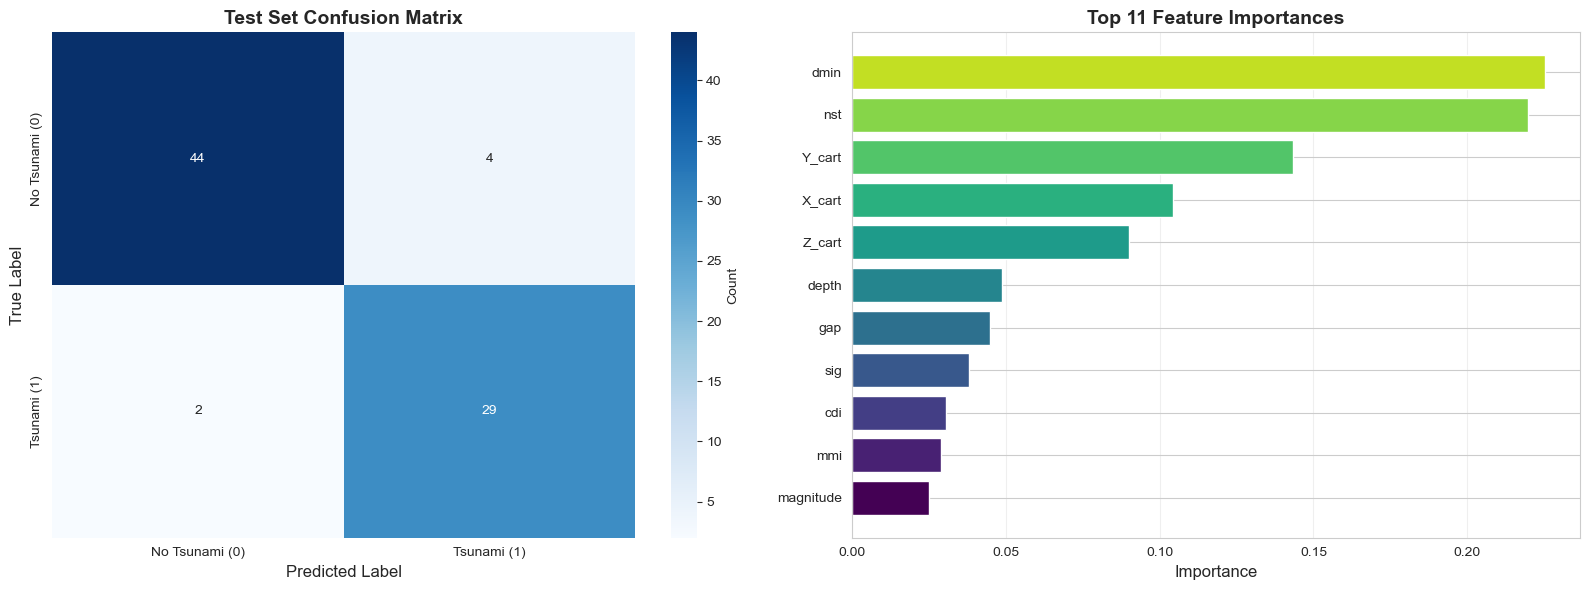

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# Set style for better-looking plots
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Heatmap (Test Set)
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'})
axes[0].set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_xticklabels(['No Tsunami (0)', 'Tsunami (1)'])
axes[0].set_yticklabels(['No Tsunami (0)', 'Tsunami (1)'])

# 2. Feature Importances Bar Chart (Top features)
# Get actual number of features
num_features = len(feature_names)
top_n = min(15, num_features)  # Use min to avoid index errors

indices = np.argsort(importances)[-top_n:]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

# Use viridis colormap properly
cmap = cm.get_cmap('viridis')
colors = [cmap(i / top_n) for i in range(top_n)]
axes[1].barh(range(top_n), top_importances, color=colors)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_features)
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()